*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders (title is 1be0.pdb)



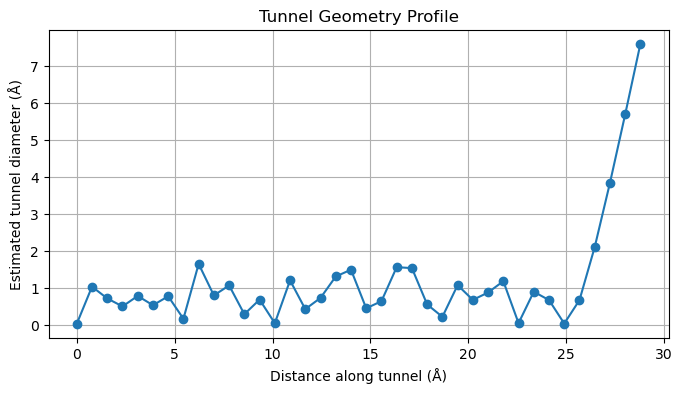

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

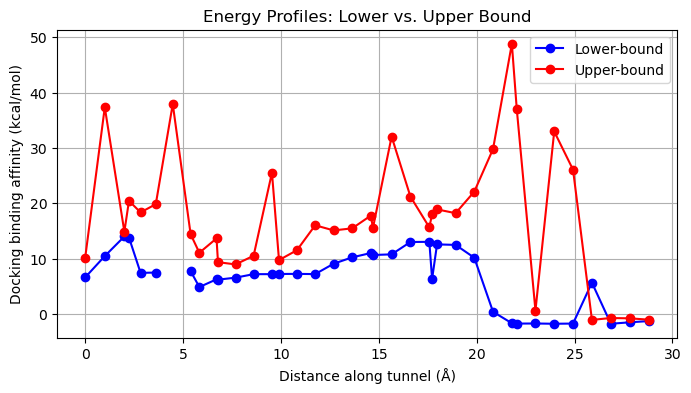

[[0.0 10.214 '']
 [1.0 37.336 '']
 [2.0 14.876 '']
 [2.23606797749979 20.446 '']
 [2.8284271247461903 18.358 '']
 [3.605551275463989 19.846 '']
 [4.47213595499958 37.917 '']
 [5.385164807134504 14.422 '']
 [5.830951894845301 11.072 '']
 [6.708203932499369 13.668 '']
 [6.782329983125268 9.375 '']
 [7.681145747868608 8.973 '']
 [8.602325267042627 10.535 '']
 [9.539392014169456 25.527 '']
 [9.899494936611665 9.75 '']
 [10.816653826391969 11.54 '']
 [11.74734012447073 16.038 '']
 [12.68857754044952 15.111 '']
 [13.638181696985855 15.481 '']
 [14.594519519326424 17.795 '']
 [14.696938456699069 15.515 '']
 [15.652475842498529 32.055 '']
 [16.61324772583615 21.212 '']
 [17.578395831246947 15.664 '']
 [17.72004514666935 18.032 '']
 [17.97220075561143 18.906 '']
 [18.920887928424502 18.221 '']
 [19.87460691435179 22.104 '']
 [20.83266665599966 29.789 '']
 [21.79449471770337 48.801 '']
 [22.045407685048602 37.007 '']
 [23.0 0.639 '']
 [23.958297101421877 32.974 '']
 [24.919871588754223 26.072 ''

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
#!/usr/bin/env python
"""
Pipeline for Pocket Identification, Tunnel Finding, and Docking

This script:
  • Loads a protein structure (and optionally an MD trajectory) using MDAnalysis,
    retaining only protein atoms.
  • Identifies a pocket center by one of several methods:
       - "atom": Use the active-site atom’s position.
       - "ligand_frame0": Use the ligand’s center-of–mass in frame 0.
       - "clustering": Use DBSCAN clustering on protein atoms near the active site to 
                     determine the pocket (returns both the centroid and the pocket atoms).
  • Uses the identified pocket center for visualization.
  • Builds a 3D grid over the entire protein and computes clearance.
  • Finds a tunnel from the active site (or nearest accessible grid point) to the grid boundary
    using a maximum–bottleneck algorithm.
  • Analyzes tunnel geometry.
  • Computes both a lower-bound energy profile (via full docking) and an upper-bound energy profile 
    (via optimization) along the tunnel.
  • Visualizes the computed tunnel, pocket, and ligand trajectories on the protein.
  • Ingestion functions use OpenBabel (pybel) to convert ligand files (SDF/MOL2) and protein files (PDB)
    to PDBQT (using the "-r" option for the protein to obtain a rigid molecule).
  
Requirements:
  - MDAnalysis, SciPy, NumPy, matplotlib, py3Dmol, scikit-learn, autodock-vina Python API,
    and OpenBabel (with pybel and openbabel).
"""

import os, tempfile
import numpy as np
import MDAnalysis as mda
from MDAnalysis.lib import distances
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import heapq
from sklearn.cluster import DBSCAN
from vina import Vina
import py3Dmol
from openbabel import pybel
from openbabel import openbabel as ob
from multiprocessing import Pool, cpu_count

### Ingestion Functions ###
def convert_to_pdbqt_ligand(input_file, output_file=None):
    ext = os.path.splitext(input_file)[1].lower()[1:]
    if output_file is None:
        base = os.path.splitext(input_file)[0]
        output_file = base + ".pdbqt"
    mols = list(pybel.readfile(ext, input_file))
    if not mols:
        raise ValueError(f"No molecules found in {input_file}")
    mol = mols[0]
    mol.addh()       # Add hydrogens (for pH ~7.4)
    mol.make3D()     # Generate 3D geometry
    mol.calccharges(model='gasteiger')
    mol.write("pdbqt", output_file, overwrite=True)
    return output_file

def convert_to_pdbqt_protein(input_file, output_file=None):
    if os.path.splitext(input_file)[1].lower() != ".pdb":
        raise ValueError("Protein input must be a PDB file.")
    if output_file is None:
        base = os.path.splitext(input_file)[0]
        output_file = base + "_rigid.pdbqt"
    conv = ob.OBConversion()
    conv.SetInFormat("pdb")
    conv.SetOutFormat("pdbqt")
    conv.AddOption("r", ob.OBConversion.OUTOPTIONS)  # rigid output
    obmol = ob.OBMol()
    conv.ReadFile(obmol, input_file)
    obmol.CorrectForPH()  # optional
    obmol.AddHydrogens()  # ensure hydrogens are present
    conv.WriteFile(obmol, output_file)
    return output_file

def universe_frame_to_pdbqt(u, output_file):
    temp_pdb = tempfile.NamedTemporaryFile(delete=False, suffix=".pdb").name
    with mda.Writer(temp_pdb) as W:
        W.write(u.atoms)
    pdbqt_file = convert_to_pdbqt_protein(temp_pdb, output_file)
    os.remove(temp_pdb)
    return pdbqt_file

def ingest_files(protein_input, ligand_input):
    protein_ext = os.path.splitext(protein_input)[1].lower()
    ligand_ext = os.path.splitext(ligand_input)[1].lower()
    if protein_ext != ".pdbqt":
        protein_pdbqt = convert_to_pdbqt_protein(protein_input)
    else:
        protein_pdbqt = protein_input
    if ligand_ext != ".pdbqt":
        ligand_pdbqt = convert_to_pdbqt_ligand(ligand_input)
    else:
        ligand_pdbqt = ligand_input
    return protein_pdbqt, ligand_pdbqt

### Pocket Identification Functions ###
def load_protein(pdb_file, trajectory_file=None):
    if trajectory_file is not None:
        u = mda.Universe(pdb_file, trajectory_file)
    else:
        u = mda.Universe(pdb_file)
    return u

def get_protein_only(u):
    return u.select_atoms("protein")

def pocket_atom(active_atom):
    return active_atom.position

def pocket_ligand_frame0(u, ligand_sel):
    ligand = u.select_atoms(ligand_sel)
    if len(ligand) == 0:
        raise ValueError("No ligand found using the provided selection in frame 0.")
    return ligand.center_of_mass()

def pocket_clustering(u, active_atom, search_radius=12.0, eps=3.0, min_samples=5):
    protein = get_protein_only(u)
    nearby = protein.select_atoms("around %f index %d" % (search_radius, active_atom.index))
    if active_atom not in nearby:
        active_ag = u.select_atoms("index %d" % active_atom.index)
        nearby = nearby.union(active_ag)
    coords = nearby.positions
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(coords)
    labels = db.labels_
    unique_labels = set(labels)
    if -1 in unique_labels:
        unique_labels.remove(-1)
    if not unique_labels:
        raise ValueError("No clusters found; try adjusting eps/min_samples.")
    centroids = {label: coords[labels == label].mean(axis=0) for label in unique_labels}
    active_pos = active_atom.position
    best_label = min(centroids.keys(), key=lambda l: np.linalg.norm(centroids[l] - active_pos))
    pocket_atoms = nearby[labels == best_label]
    return centroids[best_label], pocket_atoms

def get_pocket_center(u, method, active_site_atom_sel, ligand_sel, **kwargs):
    if method == "atom":
        active_atoms = u.select_atoms(active_site_atom_sel)
        if len(active_atoms) == 0:
            raise ValueError("No active site atom found!")
        return pocket_atom(active_atoms[0]), None
    elif method == "ligand_frame0":
        u.trajectory[0]
        return pocket_ligand_frame0(u, ligand_sel), None
    elif method == "clustering":
        active_atoms = u.select_atoms(active_site_atom_sel)
        if len(active_atoms) == 0:
            raise ValueError("No active site atom found!")
        return pocket_clustering(u, active_atoms[0], **kwargs)
    else:
        raise ValueError("Unknown pocket method: choose from 'atom', 'ligand_frame0', or 'clustering'.")

### Grid and Tunnel Functions ###
def compute_grid_bounds(u, margin):
    protein = get_protein_only(u)
    coords = protein.positions
    return coords.min(axis=0) - margin, coords.max(axis=0) + margin

def generate_grid(min_coords, max_coords, spacing):
    xs = np.arange(min_coords[0], max_coords[0] + spacing, spacing)
    ys = np.arange(min_coords[1], max_coords[1] + spacing, spacing)
    zs = np.arange(min_coords[2], max_coords[2] + spacing, spacing)
    grid = np.meshgrid(xs, ys, zs, indexing='ij')
    grid_points = np.vstack([g.ravel() for g in grid]).T
    grid_shape = (len(xs), len(ys), len(zs))
    return grid_points, grid_shape

def compute_clearance(u, grid_points, probe_radius):
    protein = get_protein_only(u)
    protein_coords = protein.positions
    tree = KDTree(protein_coords)
    dists, _ = tree.query(grid_points, k=1)
    return dists - probe_radius

def mark_accessible(clearances):
    return clearances > 0

def build_3d_arrays(grid_points, clearances, grid_shape):
    grid_3d = grid_points.reshape(grid_shape + (3,))
    clearance_3d = clearances.reshape(grid_shape)
    return grid_3d, clearance_3d

def is_boundary(idx, grid_shape):
    i, j, k = idx
    nx, ny, nz = grid_shape
    return (i == 0 or i == nx - 1 or j == 0 or j == ny - 1 or k == 0 or k == nz - 1)

def optimized_find_tunnel(active_atom, grid_3d, clearance_3d, accessible_3d):
    grid_shape = clearance_3d.shape
    flat_grid = grid_3d.reshape(-1, 3)
    active_coord = active_atom.position
    start_flat_idx = np.argmin(np.linalg.norm(flat_grid - active_coord, axis=1))
    start_idx = np.unravel_index(start_flat_idx, grid_shape)
    if not accessible_3d[start_idx]:
        accessible_indices = np.argwhere(accessible_3d)
        if accessible_indices.size == 0:
            raise ValueError("No accessible grid point found!")
        accessible_coords = np.array([grid_3d[tuple(idx)] for idx in accessible_indices])
        distances = np.linalg.norm(accessible_coords - active_coord, axis=1)
        best_idx = accessible_indices[np.argmin(distances)]
        start_idx = tuple(best_idx)
    bottleneck = -np.ones(grid_shape) * np.inf
    bottleneck[start_idx] = clearance_3d[start_idx]
    parent = {start_idx: None}
    queue = [(-bottleneck[start_idx], start_idx)]
    neighbor_offsets = [(-1, 0, 0), (1, 0, 0), (0, -1, 0),
                        (0, 1, 0), (0, 0, -1), (0, 0, 1)]
    goal_idx = None
    while queue:
        curr_val_neg, curr_idx = heapq.heappop(queue)
        curr_val = -curr_val_neg
        if is_boundary(curr_idx, grid_shape):
            goal_idx = curr_idx
            break
        i, j, k = curr_idx
        for di, dj, dk in neighbor_offsets:
            ni, nj, nk = i + di, j + dj, k + dk
            if 0 <= ni < grid_shape[0] and 0 <= nj < grid_shape[1] and 0 <= nk < grid_shape[2]:
                neighbor_idx = (ni, nj, nk)
                if not accessible_3d[neighbor_idx]:
                    continue
                new_val = min(curr_val, clearance_3d[neighbor_idx])
                if new_val > bottleneck[neighbor_idx]:
                    bottleneck[neighbor_idx] = new_val
                    parent[neighbor_idx] = curr_idx
                    heapq.heappush(queue, (-new_val, neighbor_idx))
    if goal_idx is None:
        raise ValueError("No tunnel found from active site to grid boundary!")
    path_indices = []
    curr = goal_idx
    while curr is not None:
        path_indices.append(curr)
        curr = parent.get(curr)
    path_indices.reverse()
    tunnel_path = np.array([grid_3d[idx] for idx in path_indices])
    return tunnel_path

def analyze_tunnel_geometry(u, tunnel_path, probe_radius):
    protein = get_protein_only(u)
    protein_coords = protein.positions
    tree = KDTree(protein_coords)
    radii = []
    for point in tunnel_path:
        d, _ = tree.query(point, k=1)
        local_radius = max(d - probe_radius, 0.0)
        radii.append(local_radius)
    radii = np.array(radii)
    bottleneck = radii.min()
    return radii, bottleneck

### Visualization Functions ###
def visualize_tunnel_py3dmol(tunnel_path, protein_vis_file, pocket_atoms=None, tunnel_radii=None):
    with open(protein_vis_file, 'r') as f:
        pdb_data = f.read()
    view = py3Dmol.view(width=800, height=600)
    view.addModel(pdb_data, 'pdb')
    view.setStyle({'cartoon': {'color': 'spectrum'}})
    for i, point in enumerate(tunnel_path):
        rad = float(tunnel_radii[i]) if tunnel_radii is not None else 0.5
        view.addSphere({
            'center': {'x': float(point[0]), 'y': float(point[1]), 'z': float(point[2])},
            'radius': rad, 'color': 'red', 'opacity': 0.8
        })
    if pocket_atoms is not None and len(pocket_atoms) > 0:
        for atom in pocket_atoms:
            view.addSphere({
                'center': {'x': float(atom.position[0]),
                           'y': float(atom.position[1]),
                           'z': float(atom.position[2])},
                'radius': 0.5, 'color': 'blue', 'opacity': 0.3
            })
    view.zoomTo()
    view.show()

def visualize_ligand_trajectory(trajectory_results, protein_vis_file, traj_label, color):
    """
    Visualize the ligand trajectory on the protein.
    trajectory_results should be an array of (distance, energy, ligand_pose_str).
    Each valid ligand_pose_str is added as a separate model.
    """
    with open(protein_vis_file, 'r') as f:
        pdb_data = f.read()
    view = py3Dmol.view(width=800, height=600)
    view.addModel(pdb_data, 'pdb')
    view.setStyle({'cartoon': {'color': 'spectrum'}})
    model_index = 1
    for i, (dist, energy, pose_str) in enumerate(trajectory_results):
        if pose_str is not None and len(pose_str) > 0:
            view.addModel(pose_str, 'pdb')
            view.setStyle({'model': model_index}, {'stick': {'colorscheme': color}})
            view.addLabel(f"{traj_label} {i+1}", {'model': model_index, 'backgroundColor': color, 'fontColor': 'white', 'fontSize': 10})
            model_index += 1
    view.zoomTo()
    view.show()

### Main Workflow ###
def main():
    protein_input = "1be0.pdb"          # Protein input file (for visualization)
    ligand_input = "EtOH.sdf"           # Ligand input file (SDF/MOL2)
    traj_file = None                   # Static structure
    
    active_site_atom_sel = "resid 124 and name OD2"
    pocket_method = "clustering"
    grid_spacing = 1.0
    probe_radius = 1.4
    grid_margin = 5.0
    
    # Ingest docking files (PDBQT conversion)
    protein_dock, ligand_dock = ingest_files(protein_input, ligand_input)
    
    # Load protein for analysis/visualization
    u = load_protein(protein_input, traj_file)
    active_atoms = u.select_atoms(active_site_atom_sel)
    if len(active_atoms) == 0:
        raise ValueError("No active site atom found!")
    active_atom = active_atoms[0]
    
    if pocket_method == "clustering":
        pocket_center, pocket_atoms = get_pocket_center(u, method=pocket_method,
                                                        active_site_atom_sel=active_site_atom_sel,
                                                        ligand_sel="resname LIG",
                                                        search_radius=12.0, eps=3.0, min_samples=5)
    else:
        pocket_center, pocket_atoms = get_pocket_center(u, method=pocket_method,
                                                        active_site_atom_sel=active_site_atom_sel,
                                                        ligand_sel="resname LIG")
    pocket_center = np.array(pocket_center, dtype=float)
    
    # Build grid over the whole protein
    min_coords, max_coords = compute_grid_bounds(u, grid_margin)
    grid_points, grid_shape = generate_grid(min_coords, max_coords, grid_spacing)
    
    protein_coords = get_protein_only(u).positions
    tree = KDTree(protein_coords)
    dists, _ = tree.query(grid_points, k=1)
    clearances = dists - probe_radius
    accessible = mark_accessible(clearances)
    
    grid_3d, clearance_3d = build_3d_arrays(grid_points, clearances, grid_shape)
    accessible_3d = accessible.reshape(grid_shape)
    
    try:
        tunnel_path = optimized_find_tunnel(active_atom, grid_3d, clearance_3d, accessible_3d)
    except ValueError as e:
        print("Tunnel finding error:", e)
        return
    
    radii, bottleneck = analyze_tunnel_geometry(u, tunnel_path, probe_radius)
    
    dists_profile = np.linspace(0, np.linalg.norm(tunnel_path[-1] - tunnel_path[0]), len(radii))
    plt.figure(figsize=(8, 4))
    plt.plot(dists_profile, 2 * radii, marker='o')
    plt.xlabel("Distance along tunnel (Å)")
    plt.ylabel("Estimated tunnel diameter (Å)")
    plt.title("Tunnel Geometry Profile")
    plt.grid(True)
    plt.show()
    
    visualize_tunnel_py3dmol(tunnel_path, protein_input, pocket_atoms=pocket_atoms, tunnel_radii=radii)

if __name__ == "__main__":
    main()
